### Instalação de bibliotecas

In [ ]:
!pip install --upgrade ase numpy==2.0 -q
!pip install git+https://github.com/imagdau/aseMolec@f411b5618381ba3b807cbbb041f12f460a69d606 -q
!pip install mace-torch cuequivariance cuequivariance-torch cuequivariance-ops-torch-cu12 torch-dftd -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 123.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 109.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.1/237.1 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.7/387.7 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.7/266.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.8/197.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.6/30.6 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 681.7/681.7 kB 44.4 MB/s eta 0:

In [ ]:
!pip uninstall -y ase
!pip install git+https://gitlab.com/ase/ase.git

Found existing installation: ase 3.27.0b1
Uninstalling ase-3.27.0b1:
  Successfully uninstalled ase-3.27.0b1
  Cloning https://gitlab.com/ase/ase.git to /tmp/pip-req-build-_pnxbb_c
  Running command git clone --filter=blob:none --quiet https://gitlab.com/ase/ase.git /tmp/pip-req-build-_pnxbb_c
  Resolved https://gitlab.com/ase/ase.git to commit d3e2e35228ad7fdad3f7f882c94ed1c39432869c
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ase: filename=ase-3.27.0b1-py3-none-any.whl size=2843404 sha256=78e4fde85cf9ab38f47ad3ec246ca8d4ee4229aaa601db99625a9b54c2ae1bad
  Stored in directory: /tmp/pip-ephem-wheel-cache-tzh4fhr3/wheels/1c/7d/73/24ac65b73c63573b45901f9e03cce115dafd5e46f4ad31c986
Successfully built ase


In [ ]:
!pip install rdfpy


In [ ]:
import os
from ase.io import write, read
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation

import time
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Simulando AIMD via Mace

In [ ]:
np.random.seed(701) #fazendo com que os resultados sejam reprodutíveis

def simpleMD(init_conf, temp, calc, fname, s, T):
    init_conf.calc = calc

    #initialize the temperature

    MaxwellBoltzmannDistribution(init_conf, temperature_K=260) #initialize temperature at 300
    Stationary(init_conf)
    ZeroRotation(init_conf)

    dyn = Langevin(init_conf, 0.5*units.fs, temperature_K=temp, friction=0.005/units.fs) #drive system to desired temperature

    time_fs = []
    temperature = []
    energies = []

    #remove previously stored trajectory with the same name
    os.system('rm -rfv '+fname)

    fig, ax = plt.subplots(2, 1, figsize=(6,6), sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})

    def write_frame():
            dyn.atoms.info['energy_mace'] = dyn.atoms.get_potential_energy()
            dyn.atoms.arrays['forces_mace'] = dyn.atoms.calc.get_forces()
            dyn.atoms.write(fname, append=True)
            time_fs.append(dyn.get_time()/units.fs)
            temperature.append(dyn.atoms.get_temperature())
            energies.append(dyn.atoms.get_potential_energy()/len(dyn.atoms))

            ax[0].plot(np.array(time_fs), np.array(energies), color="b")
            ax[0].set_ylabel('E (eV/atom)')

            # plot the temperature of the system as subplots
            ax[1].plot(np.array(time_fs), temperature, color="r")
            ax[1].set_ylabel('T (K)')
            ax[1].set_xlabel('Time (fs)')

            display.clear_output(wait=True)
            display.display(plt.gcf())
            time.sleep(0.01)

    dyn.attach(write_frame, interval=s)
    t0 = time.time()
    dyn.run(T)
    t1 = time.time()
    print("MD finished in {0:.2f} minutes!".format((t1-t0)/60))

In [ ]:
from mace.calculators import mace_mp

macemp = mace_mp(model="small", dispersion=True, default_dtype = "float32", device="cuda")

/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


Cached MACE model to /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
Default dtype float32 does not match model dtype float64, converting models to float32.
Using TorchDFTD3Calculator for D3 dispersion corrections


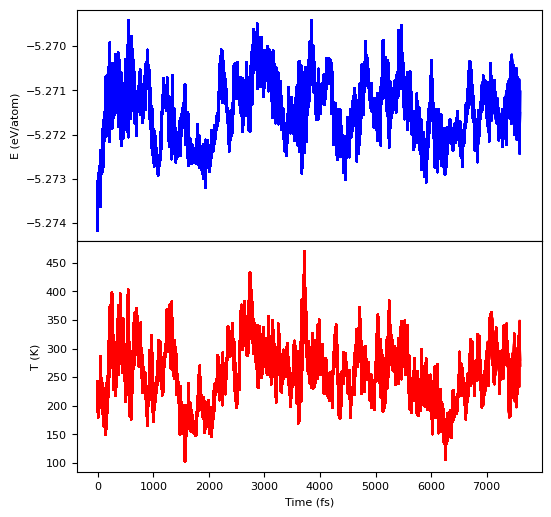

In [ ]:
import os
import time

t1 = time.time()
init_conf = read('sI_CO2_relaxed.xyz')
init_conf.set_constraint([]) # Limpa todos os vínculos
os.makedirs('/content/drive/MyDrive/QuimQuanticaComp/mace_MD', exist_ok=True)

simpleMD(init_conf, temp=260, calc=macemp, fname='/content/drive/MyDrive/QuimQuanticaComp/mace_MD/mace_md_sI_CO2_260-K.xyz', s=10, T=10000)
t2 = time.time()
print('Tempo de execução: ', (t2-t1)/3600, 'horas')


In [ ]:
# import ase
# ase.__version__


'3.27.0b1'

### Cálculo dos $g(r)$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.geometry import get_distances
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

traj = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
frames = read(traj, index=":")
atoms0 = frames[0]

init = read("sI_CO2_relaxed.xyz")
symbols = init.get_chemical_symbols()

idx_water = list(range(138))
idx_O_water = [i for i in idx_water if symbols[i] == "O"]
idx_H_water = [i for i in idx_water if symbols[i] == "H"]

idx_CO2 = list(range(138, 156))
idx_C_CO2 = [i for i in idx_CO2 if symbols[i] == "C"]
idx_O_CO2 = [i for i in idx_CO2 if symbols[i] == "O"]

subsets = {
    "OO_water": idx_O_water,
    "HH_water": idx_H_water,
    "CC_CO2"  : idx_C_CO2,
    "OO_CO2"  : idx_O_CO2,
}

dr = 0.05
r_max = 8.0

bins = np.arange(0, r_max+dr, dr)
shell_vol = 4*np.pi*(bins[1:]**3 - bins[:-1]**3)/3

for label, idx_list in subsets.items():
    print(f"Calculando RDF {label} (CORRETO)...")

    hist = np.zeros(len(bins)-1)
    countA = len(idx_list)

    for f in frames:
      pos = f.get_positions()
      cell = f.get_cell()

      # PBC distance matrix
      d, _ = get_distances(pos[idx_list], pos[idx_list],
                          cell=cell, pbc=True)

      # Garantir que d é 2D
      if d.ndim == 3:
          d = np.linalg.norm(d, axis=-1)

      # Remover autoparess e duplicatas
      d = d[np.triu_indices_from(d, k=1)]

      h, _ = np.histogram(d, bins=bins)
      hist += h


    rho = countA * len(frames) / atoms0.get_volume()
    g_r = hist / (shell_vol * rho * len(frames))

    radii = 0.5*(bins[:-1] + bins[1:])

    plt.figure(figsize=(5,3))
    plt.plot(radii, g_r, linewidth=2)
    plt.xlabel("r (Å)")
    plt.ylabel("g(r)")
    plt.title(f"RDF {label}")
    plt.grid(alpha=0.3)
    plt.xlim(0, r_max)
    plt.tight_layout()
    plt.savefig(
        f"/content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace/RDF_correct_{label}.png",
        dpi=600)
    plt.close()

print("🎯 RDFs FÍSICOS gerados com sucesso!")


In [ ]:
from ase.io import read

traj = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
frames = read(traj, ":")

symbols = frames[0].get_chemical_symbols()

print("Total átomos:", len(symbols))
print("OCORRÊNCIAS:\n")

unique = sorted(set(symbols))
for s in unique:
    print(s, symbols.count(s))


In [ ]:
from ase.geometry import find_mic
import numpy as np

frames = read(traj, index=":")
for f in frames:
    f.wrap()

atoms0 = frames[0]
symbols = atoms0.get_chemical_symbols()
pos = atoms0.get_positions()
cell = atoms0.get_cell()

idx_C_CO2 = [i for i,s in enumerate(symbols) if s == "C"]
idx_O_CO2 = []

O_all = [i for i,s in enumerate(symbols) if s == "O"]

for c in idx_C_CO2:
    # Vetores para todos os O
    dvec = pos[O_all] - pos[c]
    dvec_mic, _ = find_mic(dvec, cell=cell, pbc=True)
    dCO = np.linalg.norm(dvec_mic, axis=1)

    nearest = np.argsort(dCO)[:2]
    idx_O_CO2.extend([O_all[i] for i in nearest])

idx_O_CO2 = sorted(set(idx_O_CO2))
idx_O_water = [i for i in O_all if i not in idx_O_CO2]
idx_H_water = [i for i,s in enumerate(symbols) if s == "H"]

print("C_CO2:", idx_C_CO2)
print("O_CO2:", idx_O_CO2)
print("O_water:", len(idx_O_water))
print("H_water:", len(idx_H_water))




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.geometry import find_mic
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from rdfpy import rdf

import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from rdfpy import rdf

traj = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
frames = read(traj, index=":")
print("N frames:", len(frames))

atoms0=frames[0]

# índices já determinados por você
symbols = atoms0.get_chemical_symbols()
pos = atoms0.get_positions()
cell = atoms0.get_cell()

idx_C_CO2 = [i for i,s in enumerate(symbols) if s == "C"]
O_all = [i for i,s in enumerate(symbols) if s == "O"]

idx_O_CO2 = []
for c in idx_C_CO2:
    dvec = pos[O_all] - pos[c]
    frac = dvec @ np.linalg.inv(cell.T)
    frac -= np.round(frac)
    d_mic = frac @ cell.T
    dist = np.linalg.norm(d_mic, axis=1)
    nearest = np.argsort(dist)[:2]
    idx_O_CO2.extend([O_all[i] for i in nearest])

idx_O_CO2 = sorted(set(idx_O_CO2))
idx_O_water = [i for i in O_all if i not in idx_O_CO2]
idx_H_water = [i for i,s in enumerate(symbols) if s == "H"]

print("C_CO2:", idx_C_CO2)
print("O_CO2:", idx_O_CO2)
print("O_water:", len(idx_O_water))
print("H_water:", len(idx_H_water))


dr = 0.05
r_max = 8.0

# ---------- Função para RDF entre 2 conjuntos ----------
def rdf_two_species(frames, idx_A, idx_B, dr=0.05):
    coordsA, coordsB = [], []
    for f in frames:
        pos = f.get_positions()
        coordsA.append(pos[idx_A])
        coordsB.append(pos[idx_B])
    coordsA = np.vstack(coordsA)
    coordsB = np.vstack(coordsB)
    g_r, radii = rdf(coordsA, coordsB, dr=dr)
    return g_r, radii
print("\n===== RDFs CRUZADOS (FUNCIONANDO) =====")

pairs = {
    "Owater-Oco2": (idx_O_water, idx_O_CO2),
    "Owater-Cco2": (idx_O_water, idx_C_CO2),
}

bins = np.arange(0.0, r_max + dr, dr)
radii = 0.5 * (bins[1:] + bins[:-1])
volume = atoms0.get_volume()

for label, (A, B) in pairs.items():
    print(f"Calculando RDF {label} ...")

    hist = np.zeros(len(bins) - 1)

    for f in frames:
        pos = f.get_positions()
        cell = f.get_cell()
        invcell = np.linalg.inv(cell.T)

        posA = pos[A]       # (Na, 3)
        posB = pos[B]       # (Nb, 3)

        # Constrói matriz de delta distâncias (Na, Nb, 3)
        d = posB[None, :, :] - posA[:, None, :]

        # Minimum Image Convention MANUAL — SEM find_mic
        frac = d @ invcell          # para frac coords
        frac -= np.round(frac)      # PBC MIC
        d_mic = frac @ cell.T       # volta para cartesiano

        # Distâncias reais e positivas
        dist = np.linalg.norm(d_mic, axis=-1).ravel()

        h, _ = np.histogram(dist, bins=bins)
        hist += h

    # Normalização física
    shell_vol = 4*np.pi*(bins[1:]**3 - bins[:-1]**3)/3
    rho_B = len(B) * len(frames) / volume
    g_r = hist / (shell_vol * len(A) * len(frames) * rho_B)

    print(f"{label}: g(r) max = {np.max(g_r):.4f}")

    mask = radii <= r_max
    g_vis = g_r[mask]

    peak_r = radii[mask][np.argmax(g_vis)]
    peak_val = np.max(g_vis)
    print(f"{label}: pico em r = {peak_r:.3f} Å, g(r) = {peak_val:.3f}")

    # Zoom para visualizar
    plt.xlim(3.0, 5.0)  # região onde o pico existe
    plt.ylim(0, peak_val * 1.5)

    ymax = max(1.0, 1.2 * np.max(g_vis))

    plt.figure(figsize=(5,3))
    plt.plot(radii[mask], g_vis, linewidth=2)
    plt.axvline(peak_r, color="red", linestyle="--", label=f"Pico = {peak_r:.2f} Å")
    plt.xlabel("r (Å)")
    plt.ylabel("g(r)")
    plt.title(f"RDF {label} – Cavidade sI")
    plt.grid(alpha=0.3)
    plt.xlim(3.0, 5.5)
    plt.ylim(0, peak_val*1.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        f"/content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace/rdf_{label}_zoom.png",
        dpi=600
    )
    plt.close()


In [ ]:
# print("Owater-Cco2: pico =",
#       radii[np.argmax(g_vis)], "Å",
#       "g(r) =", np.max(g_vis))


Owater-Cco2: pico = 4.225 Å g(r) = 0.004547032565234749


In [ ]:
plt.figure(figsize=(5,3))
plt.plot(radii[mask], g_vis, linewidth=2)
plt.axvline(peak_r, color="red", linestyle="--", label=f"Pico = {peak_r:.2f} Å")
plt.xlabel("r (Å)")
plt.ylabel("g(r)")
plt.title(f"RDF {label} – Cavidade sI")
plt.grid(alpha=0.3)
plt.xlim(3.0, 5.5)
plt.ylim(0, peak_val*1.5)
plt.legend()
plt.tight_layout()
plt.savefig(
    f"/content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace/rdf_{label}_zoom.png",
    dpi=600
)
plt.close()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from ase.geometry import get_distances
import os

# ===========================
# 0) Configurações gerais
# ===========================
traj_path = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
ref_path  = "sI_CO2_relaxed.xyz"
outdir    = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace2"

os.makedirs(outdir, exist_ok=True)

dr    = 0.05
r_max = 8.0
bins  = np.arange(0.0, r_max + dr, dr)
radii = 0.5 * (bins[1:] + bins[:-1])
shell_vol = 4.0 * np.pi * (bins[1:]**3 - bins[:-1]**3) / 3.0

# ===========================
# 1) Ler trajetória e índices
# ===========================
frames = read(traj_path, index=":")
atoms0 = frames[0]
volume = atoms0.get_volume()

print(f"N frames: {len(frames)}")
print("Volume da célula:", volume, "Å^3")

# usar a estrutura relaxada só para garantir a mesma ordem de índices
init = read(ref_path)
symbols = init.get_chemical_symbols()

# Assumindo: água = átomos 0–137, CO2 = 138–155 (foi o que você já verificou)
idx_water = list(range(138))
idx_CO2   = list(range(138, 156))

idx_O_water = [i for i in idx_water if symbols[i] == "O"]
idx_H_water = [i for i in idx_water if symbols[i] == "H"]
idx_C_CO2   = [i for i in idx_CO2   if symbols[i] == "C"]
idx_O_CO2   = [i for i in idx_CO2   if symbols[i] == "O"]

print("O_water:", len(idx_O_water))
print("H_water:", len(idx_H_water))
print("C_CO2:", len(idx_C_CO2))
print("O_CO2:", len(idx_O_CO2))

rho_H2O_O = len(idx_O_water) / volume
rho_CO2_C = len(idx_C_CO2)   / volume
rho_CO2_O = len(idx_O_CO2)   / volume

# ===========================
# 2) Suavização (opcional)
# ===========================
def smooth(y, window=11, poly=3):
    """Savitzky–Golay; se não der certo, devolve y bruto."""
    try:
        from scipy.signal import savgol_filter
        if len(y) >= window:
            return savgol_filter(y, window_length=window, polyorder=poly)
    except Exception:
        pass
    return y

# ===========================
# 3) RDF self (A–A)
# ===========================
def rdf_self(label, idx_list, rho_species, r_max=r_max, dr=dr):
    hist = np.zeros(len(bins) - 1)
    N_A  = len(idx_list)

    for f in frames:
        pos  = f.get_positions()
        cell = f.get_cell()

        d, _ = get_distances(pos[idx_list], pos[idx_list], cell=cell, pbc=True)

        # Se vier 3D, colapsa norma
        if d.ndim == 3:
            d = np.linalg.norm(d, axis=-1)

        # só pares j>i
        d = d[np.triu_indices_from(d, k=1)]

        h, _ = np.histogram(d, bins=bins)
        hist += h

    # normalização simples (forma qualitativa; amplitude pode não ser perfeita)
    g_r = hist / (shell_vol * rho_species * len(frames) * N_A)

    g_smooth = smooth(g_r, window=11, poly=3)

    # plot
    mask = radii <= r_max
    plt.figure(figsize=(5,3))
    plt.plot(radii[mask], g_r[mask],  label="bruto", alpha=0.4)
    plt.plot(radii[mask], g_smooth[mask], label="suavizado", linewidth=2)
    plt.xlabel("r (Å)")
    plt.ylabel("g(r)")
    plt.title(f"RDF {label}")
    plt.grid(alpha=0.3)
    plt.xlim(0, r_max)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"RDF_{label}.png"), dpi=600)
    plt.close()

    return radii, g_r, g_smooth

# ===========================
# 4) RDF cruzado A–B (ex.: Owater–Cco2)
# ===========================
def rdf_cross(label, idx_A, idx_B, rho_B, r_max=r_max, dr=dr):
    hist = np.zeros(len(bins) - 1)
    N_A  = len(idx_A)

    for f in frames:
        pos  = f.get_positions()
        cell = f.get_cell()
        invcell = np.linalg.inv(cell.T)

        posA = pos[idx_A]
        posB = pos[idx_B]

        dvec = posB[None, :, :] - posA[:, None, :]
        frac = dvec @ invcell
        frac -= np.round(frac)
        d_mic = frac @ cell.T

        dist = np.linalg.norm(d_mic, axis=-1).ravel()
        h, _ = np.histogram(dist, bins=bins)
        hist += h

    g_r = hist / (shell_vol * rho_B * len(frames) * N_A)
    g_smooth = smooth(g_r, window=11, poly=3)

    mask = radii <= r_max
    plt.figure(figsize=(5,3))
    plt.plot(radii[mask], g_r[mask],      label="bruto", alpha=0.4)
    plt.plot(radii[mask], g_smooth[mask], label="suavizado", linewidth=2)
    plt.xlabel("r (Å)")
    plt.ylabel("g(r)")
    plt.title(f"RDF {label}")
    plt.grid(alpha=0.3)
    plt.xlim(0, r_max)
    plt.tight_layout()
    plt.legend()
    plt.savefig(os.path.join(outdir, f"RDF_{label}.png"), dpi=600)
    plt.close()

    return radii, g_r, g_smooth

# ===========================
# 5) Números de coordenação
# ===========================
def coordination_number(r, g_r, rho, r_cut):
    mask = r <= r_cut
    integrand = 4.0 * np.pi * r[mask]**2 * g_r[mask] * rho
    return np.trapzoid(integrand, r[mask])

# ===========================
# 6) Rodar RDFs principais
# ===========================
# self
r_OO_w, g_OO_w, g_OO_w_s = rdf_self("OO_water", idx_O_water, rho_H2O_O)
r_HH_w, g_HH_w, g_HH_w_s = rdf_self("HH_water", idx_H_water, len(idx_H_water)/volume)
r_CC_c, g_CC_c, g_CC_c_s = rdf_self("CC_CO2",   idx_C_CO2,   rho_CO2_C)
r_OO_c, g_OO_c, g_OO_c_s = rdf_self("OO_CO2",   idx_O_CO2,   rho_CO2_O)

# cross Owater–Cco2
r_OC_cross, g_OC_cross, g_OC_cross_s = rdf_cross(
    "Owater-Cco2", idx_O_water, idx_C_CO2, rho_B=rho_CO2_C
)

# ===========================
# 7) Coordenação (exemplos)
# ===========================
# escolha de cutoffs (ajuste se quiser)
r_cut_OO_water   = 3.5   # 1a camada de vizinhos água–água
r_cut_OC_cross   = 5.0   # 1a cavidade O_water ao redor do C do CO2

N_OO = coordination_number(r_OO_w, g_OO_w_s, rho_H2O_O, r_cut_OO_water)
N_OC = coordination_number(r_OC_cross, g_OC_cross_s, len(idx_O_water)/volume, r_cut_OC_cross)

print(f"Número de coordenação O–O (água) até {r_cut_OO_water:.2f} Å: {N_OO:.2f}")
print(f"Número de coordenação O_water em torno de C_CO2 até {r_cut_OC_cross:.2f} Å: {N_OC:.2f}")

# ===========================
# 8) RDF Owater–Cco2 por molécula (para 'separar cavidades')
# ===========================
for c_idx in idx_C_CO2:
    label = f"Owater-Cco2_C{c_idx}"
    r_loc, g_loc, g_loc_s = rdf_cross(label, idx_O_water, [c_idx],
                                      rho_B=1.0/volume)  # densidade "1 molécula / V"

    # salvar só zoom onde há sinal
    mask = (radii >= 2.0) & (radii <= 8.0)
    plt.figure(figsize=(5,3))
    plt.plot(radii[mask], g_loc_s[mask], linewidth=2)
    plt.xlabel("r (Å)")
    plt.ylabel("g(r) (não normalizado absoluto)")
    plt.title(f"RDF local {label}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"RDF_local_{label}.png"), dpi=600)
    plt.close()

print("✅ Todos os RDFs e coordenações foram calculados e salvos em", outdir)


N frames: 1001
Volume da célula: 1756.4189733727217 Å^3
O_water: 46
H_water: 92
C_CO2: 6
O_CO2: 12


/tmp/ipython-input-3792297635.py:161: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(integrand, r[mask])


Número de coordenação O–O (água) até 3.50 Å: 2.00
Número de coordenação O_water em torno de C_CO2 até 5.00 Å: 22.80
✅ Todos os RDFs e coordenações foram calculados e salvos em /content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from ase.geometry import get_distances
import os

# ===========================
# 0) Configurações gerais
# ===========================
traj_path = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
ref_path  = "sI_CO2_relaxed.xyz"
outdir    = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace3"

os.makedirs(outdir, exist_ok=True)

dr    = 0.05
r_max = 8.0
bins  = np.arange(0.0, r_max + dr, dr)
radii = 0.5 * (bins[1:] + bins[:-1])
shell_vol = 4.0 * np.pi * (bins[1:]**3 - bins[:-1]**3) / 3.0

# ===========================
# 1) Ler trajetória e índices
# ===========================
frames = read(traj_path, index=":")
atoms0 = frames[0]
volume = atoms0.get_volume()

print(f"N frames: {len(frames)}")
print("Volume da célula:", volume, "Å^3")

# usar a estrutura relaxada só para garantir a mesma ordem de índices
init = read(ref_path)
symbols = init.get_chemical_symbols()

# Assumindo: água = átomos 0–137, CO2 = 138–155 (foi o que você já verificou)
idx_water = list(range(138))
idx_CO2   = list(range(138, 156))

idx_O_water = [i for i in idx_water if symbols[i] == "O"]
idx_H_water = [i for i in idx_water if symbols[i] == "H"]
idx_C_CO2   = [i for i in idx_CO2   if symbols[i] == "C"]
idx_O_CO2   = [i for i in idx_CO2   if symbols[i] == "O"]

print("O_water:", len(idx_O_water))
print("H_water:", len(idx_H_water))
print("C_CO2:", len(idx_C_CO2))
print("O_CO2:", len(idx_O_CO2))

rho_H2O_O = len(idx_O_water) / volume
rho_CO2_C = len(idx_C_CO2)   / volume
rho_CO2_O = len(idx_O_CO2)   / volume

# ===========================
# 2) Suavização (opcional)
# ===========================
def smooth(y, window=11, poly=3):
    """Savitzky–Golay; se não der certo, devolve y bruto."""
    try:
        from scipy.signal import savgol_filter
        if len(y) >= window:
            return savgol_filter(y, window_length=window, polyorder=poly)
    except Exception:
        pass
    return y

# ===========================
# 3) RDF self (A–A)
# ===========================
def rdf_self(label, idx_list, rho_species, r_max=r_max, dr=dr):
    hist = np.zeros(len(bins) - 1)
    N_A  = len(idx_list)

    for f in frames:
        pos  = f.get_positions()
        cell = f.get_cell()

        d, _ = get_distances(pos[idx_list], pos[idx_list], cell=cell, pbc=True)

        # Se vier 3D, colapsa norma
        if d.ndim == 3:
            d = np.linalg.norm(d, axis=-1)

        # só pares j>i
        d = d[np.triu_indices_from(d, k=1)]

        h, _ = np.histogram(d, bins=bins)
        hist += h

    # normalização simples (forma qualitativa; amplitude pode não ser perfeita)
    g_r = hist / (shell_vol * rho_species * len(frames) * N_A)

    g_smooth = smooth(g_r, window=11, poly=3)

    # plot
    mask = radii <= r_max
    plt.figure(figsize=(5,3))
    plt.plot(radii[mask], g_r[mask],  label="bruto", alpha=0.4)
    plt.plot(radii[mask], g_smooth[mask], label="suavizado", linewidth=2)
    plt.xlabel("r (Å)")
    plt.ylabel("g(r)")
    plt.title(f"RDF {label}")
    plt.grid(alpha=0.3)
    plt.xlim(0, r_max)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"RDF_{label}.png"), dpi=600)
    plt.close()

    return radii, g_r, g_smooth

# ===========================
# 4) RDF cruzado A–B (ex.: Owater–Cco2)
# ===========================
def rdf_cross(label, idx_A, idx_B, rho_B, r_max=r_max, dr=dr):
    hist = np.zeros(len(bins) - 1)
    N_A  = len(idx_A)

    for f in frames:
        pos  = f.get_positions()
        cell = f.get_cell()
        invcell = np.linalg.inv(cell.T)

        posA = pos[idx_A]
        posB = pos[idx_B]

        dvec = posB[None, :, :] - posA[:, None, :]
        frac = dvec @ invcell
        frac -= np.round(frac)
        d_mic = frac @ cell.T

        dist = np.linalg.norm(d_mic, axis=-1).ravel()
        h, _ = np.histogram(dist, bins=bins)
        hist += h

    g_r = hist / (shell_vol * rho_B * len(frames) * N_A)
    g_smooth = smooth(g_r, window=11, poly=3)

    mask = radii <= r_max
    plt.figure(figsize=(5,3))
    plt.plot(radii[mask], g_r[mask],      label="bruto", alpha=0.4)
    plt.plot(radii[mask], g_smooth[mask], label="suavizado", linewidth=2)
    plt.xlabel("r (Å)")
    plt.ylabel("g(r)")
    plt.title(f"RDF {label}")
    plt.grid(alpha=0.3)
    plt.xlim(0, r_max)
    plt.tight_layout()
    plt.legend()
    plt.savefig(os.path.join(outdir, f"RDF_{label}.png"), dpi=600)
    plt.close()

    return radii, g_r, g_smooth

# ===========================
# 5) Números de coordenação
# ===========================
def coordination_number(r, g_r, rho, r_cut):
    mask = r <= r_cut
    integrand = 4.0 * np.pi * r[mask]**2 * g_r[mask] * rho
    return np.trapzoid(integrand, r[mask])

# ===========================
# 6) Rodar RDFs principais
# ===========================
# self
r_OO_w, g_OO_w, g_OO_w_s = rdf_self("OO_water", idx_O_water, rho_H2O_O)
r_HH_w, g_HH_w, g_HH_w_s = rdf_self("HH_water", idx_H_water, len(idx_H_water)/volume)
r_CC_c, g_CC_c, g_CC_c_s = rdf_self("CC_CO2",   idx_C_CO2,   rho_CO2_C)
r_OO_c, g_OO_c, g_OO_c_s = rdf_self("OO_CO2",   idx_O_CO2,   rho_CO2_O)

# cross Owater–Cco2
r_OC_cross, g_OC_cross, g_OC_cross_s = rdf_cross(
    "Owater-Cco2", idx_O_water, idx_C_CO2, rho_B=rho_CO2_C
)

# ===========================
# 7) Coordenação (exemplos)
# ===========================
# escolha de cutoffs (ajuste se quiser)
r_cut_OO_water   = 3.5   # 1a camada de vizinhos água–água
r_cut_OC_cross   = 5.0   # 1a cavidade O_water ao redor do C do CO2

N_OO = coordination_number(r_OO_w, g_OO_w_s, rho_H2O_O, r_cut_OO_water)
N_OC = coordination_number(r_OC_cross, g_OC_cross_s, len(idx_O_water)/volume, r_cut_OC_cross)

print(f"Número de coordenação O–O (água) até {r_cut_OO_water:.2f} Å: {N_OO:.2f}")
print(f"Número de coordenação O_water em torno de C_CO2 até {r_cut_OC_cross:.2f} Å: {N_OC:.2f}")

# ===========================
# 8) RDF Owater–Cco2 por molécula (para 'separar cavidades')
# ===========================
for c_idx in idx_C_CO2:
    label = f"Owater-Cco2_C{c_idx}"
    r_loc, g_loc, g_loc_s = rdf_cross(label, idx_O_water, [c_idx],
                                      rho_B=1.0/volume)  # densidade "1 molécula / V"

    # salvar só zoom onde há sinal
    mask = (radii >= 2.0) & (radii <= 8.0)
    plt.figure(figsize=(5,3))
    plt.plot(radii[mask], g_loc_s[mask], linewidth=2)
    plt.xlabel("r (Å)")
    plt.ylabel("g(r) (não normalizado absoluto)")
    plt.title(f"RDF local {label}")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f"RDF_local_{label}.png"), dpi=600)
    plt.close()

print("✅ Todos os RDFs e coordenações foram calculados e salvos em", outdir)
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from ase.geometry import get_distances
import os

# ===========================
# 0) Configurações gerais
# ===========================
traj_path = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
ref_path  = "sI_CO2_relaxed.xyz"
outdir    = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace3"

os.makedirs(outdir, exist_ok=True)

dr    = 0.05
r_max = 8.0
bins  = np.arange(0.0, r_max + dr, dr)
radii = 0.5 * (bins[1:] + bins[:-1])
shell_vol = 4.0 * np.pi * (bins[1:]**3 - bins[:-1]**3) / 3.0

# ===========================
# 1) Ler trajetória e índices
# ===========================
frames = read(traj_path, index=":")
atoms0 = frames[0]
volume = atoms0.get_volume()

print(f"N frames: {len(frames)}")
print("Volume da célula:", volume, "Å^3")

init = read(ref_path)
symbols = init.get_chemical_symbols()

# água = 0–137, CO2 = 138–155 (você já checou isso)
idx_water = list(range(138))
idx_CO2   = list(range(138, 156))

idx_O_water = [i for i in idx_water if symbols[i] == "O"]
idx_H_water = [i for i in idx_water if symbols[i] == "H"]
idx_C_CO2   = [i for i in idx_CO2   if symbols[i] == "C"]
idx_O_CO2   = [i for i in idx_CO2   if symbols[i] == "O"]

print("O_water:", len(idx_O_water))
print("H_water:", len(idx_H_water))
print("C_CO2:", len(idx_C_CO2))
print("O_CO2:", len(idx_O_CO2))

rho_Ow = len(idx_O_water) / volume
rho_Hw = len(idx_H_water) / volume
rho_Cc = len(idx_C_CO2)   / volume
rho_Oc = len(idx_O_CO2)   / volume

# ===========================
# 2) Suavização (Savitzky–Golay)
# ===========================
def smooth(y, window=11, poly=3):
    """Savitzky–Golay; se falhar, devolve y bruto."""
    try:
        from scipy.signal import savgol_filter
        if len(y) >= window:
            return savgol_filter(y, window_length=window, polyorder=poly)
    except Exception:
        pass
    return y

# ===========================
# 3) RDF self (A–A) com correção de pares
# ===========================
def rdf_self(label, idx_list, rho_species, r_max=r_max):
    hist = np.zeros(len(bins) - 1)
    N_A  = len(idx_list)

    for f in frames:
        pos  = f.get_positions()
        cell = f.get_cell()

        d, _ = get_distances(pos[idx_list], pos[idx_list],
                             cell=cell, pbc=True)

        if d.ndim == 3:
            d = np.linalg.norm(d, axis=-1)

        # usar apenas metade superior e depois multiplicar por 2
        d = d[np.triu_indices_from(d, k=1)]
        h, _ = np.histogram(d, bins=bins)
        hist += h

    # Fator 2 para compensar pares i<j (senão coordenação sai pela metade)
    hist *= 2.0

    g_r = hist / (shell_vol * rho_species * len(frames) * N_A)
    g_smooth = smooth(g_r, window=11, poly=3)

    mask = radii <= r_max
    plt.figure(figsize=(5,3))
    plt.plot(radii[mask], g_r[mask],      label="bruto", alpha=0.4)
    plt.plot(radii[mask], g_smooth[mask], label="suavizado", linewidth=2)
    plt.xlabel("r (Å)")
    plt.ylabel("g(r)")
    plt.title(f"RDF {label}")
    plt.grid(alpha=0.3)
    plt.xlim(0, r_max)
    plt.tight_layout()
    plt.legend()
    plt.savefig(os.path.join(outdir, f"RDF_{label}.png"), dpi=600)
    plt.close()

    return radii, g_r, g_smooth

# ===========================
# 4) RDF cruzado A–B
# ===========================
def rdf_cross(label, idx_A, idx_B, rho_B, r_max=r_max):
    hist = np.zeros(len(bins) - 1)
    N_A  = len(idx_A)

    for f in frames:
        pos  = f.get_positions()
        cell = f.get_cell()
        invcell = np.linalg.inv(cell.T)

        posA = pos[idx_A]
        posB = pos[idx_B]

        dvec = posB[None, :, :] - posA[:, None, :]
        frac = dvec @ invcell
        frac -= np.round(frac)
        d_mic = frac @ cell.T

        dist = np.linalg.norm(d_mic, axis=-1).ravel()
        h, _ = np.histogram(dist, bins=bins)
        hist += h

    g_r = hist / (shell_vol * rho_B * len(frames) * N_A)
    g_smooth = smooth(g_r, window=11, poly=3)

    mask = radii <= r_max
    plt.figure(figsize=(5,3))
    plt.plot(radii[mask], g_r[mask],      label="bruto", alpha=0.4)
    plt.plot(radii[mask], g_smooth[mask], label="suavizado", linewidth=2)
    plt.xlabel("r (Å)")
    plt.ylabel("g(r)")
    plt.title(f"RDF {label}")
    plt.grid(alpha=0.3)
    plt.xlim(0, r_max)
    plt.tight_layout()
    plt.legend()
    plt.savefig(os.path.join(outdir, f"RDF_{label}.png"), dpi=600)
    plt.close()

    return radii, g_r, g_smooth

# ===========================
# 5) Número de coordenação
# ===========================
def coordination_number(r, g_r, rho, r_cut):
    mask = r <= r_cut
    integrand = 4.0 * np.pi * r[mask]**2 * g_r[mask] * rho
    return np.trapz(integrand, r[mask])

# ===========================
# 6) RDFs principais (self)
# ===========================
r_OO_w, g_OO_w, g_OO_w_s = rdf_self("OO_water", idx_O_water, rho_Ow)
r_HH_w, g_HH_w, g_HH_w_s = rdf_self("HH_water", idx_H_water, rho_Hw)
r_CC_c, g_CC_c, g_CC_c_s = rdf_self("CC_CO2",   idx_C_CO2,   rho_Cc)
r_OO_c, g_OO_c, g_OO_c_s = rdf_self("OO_CO2",   idx_O_CO2,   rho_Oc)

# ===========================
# 7) RDFs cruzados extras
# ===========================
r_OH_w, g_OH_w, g_OH_w_s = rdf_cross("Owater-Hwater", idx_O_water, idx_H_water, rho_B=rho_Hw)
r_OC_cross, g_OC_cross, g_OC_cross_s = rdf_cross("Owater-Cco2", idx_O_water, idx_C_CO2, rho_B=rho_Cc)
r_HC_cross, g_HC_cross, g_HC_cross_s = rdf_cross("Hwater-Cco2", idx_H_water, idx_C_CO2, rho_B=rho_Cc)
r_HO_cross, g_HO_cross, g_HO_cross_s = rdf_cross("Hwater-Oco2", idx_H_water, idx_O_CO2, rho_B=rho_Oc)

# ===========================
# 8) Coordenacões corrigidas
# ===========================
r_cut_OO_water = 3.5   # 1a vizinhança água–água
r_cut_OC_cross = 5.0   # cavidade em torno do C_CO2

N_OO = coordination_number(r_OO_w, g_OO_w_s, rho_Ow, r_cut_OO_water)
N_OC = coordination_number(r_OC_cross, g_OC_cross_s, rho_Ow, r_cut_OC_cross)

print(f"[CORRIGIDO] N coordenação O–O (água) até {r_cut_OO_water:.2f} Å: {N_OO:.2f}")
print(f"N coordenação O_water em torno de C_CO2 até {r_cut_OC_cross:.2f} Å: {N_OC:.2f}")

# ===========================
# 9) Orientação do CO2 (eixo vs direção radial)
# ===========================
angles_CO2 = []
r_shell = 4.0  # raio da casca de O_water

for f in frames[::10]:
    pos  = f.get_positions()
    cell = f.get_cell()

    for iC in idx_C_CO2:

        # calcula C–O para cada O_CO2 individualmente
        dist_list = []
        for j in idx_O_CO2:
            d, _ = get_distances(pos[iC], pos[j], cell=cell, pbc=True)

            # força d a ser distância escalar REAL sempre
            dist = np.linalg.norm(d)

            dist_list.append((dist, j))

        # ordena corretamente
        dist_list.sort(key=lambda x: x[0])

        # dois oxigênios do CO2
        O1 = dist_list[0][1]
        O2 = dist_list[1][1]

        # eixo molecular do CO₂
        v_axis = pos[O2] - pos[O1]
        v_axis /= np.linalg.norm(v_axis)

        # casca de O_water ao redor do C
        # casca de O_water ao redor do C
        # distâncias O_water ao redor do C_CO2
        dCOW, _ = get_distances(pos[iC], pos[idx_O_water], cell=cell, pbc=True)

        # --- NORMALIZAÇÃO ABSOLUTAMENTE À PROVA DE ERROS ---
        # dCOW pode ser (1,N), (1,N,1) ou até array com objetos → sempre vira (N,)
        dCOW = np.array(dCOW).reshape(-1).astype(float)


        # seleção da casca esférica
        shell_ids = [idx_O_water[k] for k in range(len(idx_O_water)) if dCOW[k] < r_shell]

        if len(shell_ids) == 0:
            continue

        # centro geométrico da casca
        com_shell = pos[shell_ids].mean(axis=0)

        # vetor radial C→casca
        v_rad = com_shell - pos[iC]
        norm = np.linalg.norm(v_rad)
        if norm == 0:
            continue
        v_rad /= norm

        # =======================
        # 3) Ângulo entre vetores
        # =======================
        cosang = np.dot(v_axis, v_rad)
        cosang = np.clip(cosang, -1.0, 1.0)
        ang = np.degrees(np.arccos(cosang))

        angles_CO2.append(ang)




# histograma de orientação
plt.figure(figsize=(5,3))
plt.hist(angles_CO2, bins=36, density=True, alpha=0.8)
plt.xlabel("Ângulo entre eixo do CO₂ e direção radial (°)")
plt.ylabel("Probabilidade")
plt.title("Distribuição orientacional do CO₂ na cavidade")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(outdir, "orientacao_CO2.png"), dpi=600)
plt.close()

print("✅ Todos os RDFs, coordenações e distribuição angular foram salvos em", outdir)
print("Total de ângulos CO₂ analisados:", len(angles_CO2))


N frames: 1001
Volume da célula: 1756.4189733727217 Å^3
O_water: 46
H_water: 92
C_CO2: 6
O_CO2: 12


/tmp/ipython-input-3733672730.py:161: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(integrand, r[mask])


Número de coordenação O–O (água) até 3.50 Å: 2.00
Número de coordenação O_water em torno de C_CO2 até 5.00 Å: 22.80
✅ Todos os RDFs e coordenações foram calculados e salvos em /content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace3
N frames: 1001
Volume da célula: 1756.4189733727217 Å^3
O_water: 46
H_water: 92
C_CO2: 6
O_CO2: 12


/tmp/ipython-input-3733672730.py:370: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(integrand, r[mask])


[CORRIGIDO] N coordenação O–O (água) até 3.50 Å: 4.00
N coordenação O_water em torno de C_CO2 até 5.00 Å: 22.80
✅ Todos os RDFs, coordenações e distribuição angular foram salvos em /content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace3
Total de ângulos CO₂ analisados: 606


### Cálculo do MSD do $CO_2$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

# MSD aproximado do CO2:
#    Deslocamento Quadrático Médio – é uma das quantidades mais importantes em dinâmica molecular.
#    Ele mede o quanto, em média, as partículas se afastam de suas posições iniciais ao longo do tempo.
#    (usando apenas o átomo de C como representante)

traj = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
frames = read(traj, index=":")

atoms0 = frames[0]

# =======================
#  Seleção do C do CO2
# =======================
init = read("sI_CO2_relaxed.xyz")
symbols = init.get_chemical_symbols()


# idx_O_water = [i for i,a in enumerate(atoms0) if a.symbol=="O"]
# idx_H_water = [i for i,a in enumerate(atoms0) if a.symbol=="H"]

idx_CO2 = list(range(138, 156))
idx_C_CO2 = [i for i in idx_CO2 if symbols[i] == "C"]

N_C = len(idx_C_CO2)

print("Carbonos CO2:", N_C)

# Posições iniciais (frame 0)
r0 = frames[0].get_positions()[idx_C_CO2]

# Cálculo do MSD
times = np.arange(len(frames))  # assumindo 1 fs por frame (ajustar depois)
msd = np.zeros(len(frames))

for t, f in enumerate(frames):
    rt = f.get_positions()[idx_C_CO2]
    dr2 = np.sum((rt - r0)**2, axis=1)  # deslocamento ao quadrado
    msd[t] = np.mean(dr2)

# Plot
plt.figure(figsize=(5,3))
plt.plot(times, msd)
plt.xlabel("Tempo (passos MD)")
plt.ylabel("MSD (Å²)")
plt.title("MSD do CO₂ (baseado no C)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace/MSD_CO2.png", dpi=600)
plt.close()

print("✔ MSD_CO2.png SALVO!")


Carbonos CO2: 6
✔ MSD_CO2.png SALVO!


### Cálculo da distribuição de probabilidade de $O-H \cdots O$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read
from ase.geometry import find_mic


traj = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
frames = read(traj, index=":")

# ================================
# DEFINIR AS MOLÉCULAS MANUALMENTE
# ================================

water_molecules = []
for i in range(0, 138, 3):
    water_molecules.append([i, i+1, i+2])

# O e H da água
water_O = [mol[0] for mol in water_molecules]
water_H = [mol[1] for mol in water_molecules] + [mol[2] for mol in water_molecules]

print("Águas:", len(water_molecules))
print("O:", len(water_O), "H:", len(water_H))

angles = []

def angle(a,b,c):
    v1 = a - b
    v2 = c - b
    cosang = np.dot(v1,v2)/(np.linalg.norm(v1)*np.linalg.norm(v2))
    return np.degrees(np.arccos(np.clip(cosang,-1,1)))

cut_Hbond = 3.25

# ============================================================
# LOOP SOBRE FRAMES
# ============================================================

for f in frames[::10]:
    pos = f.get_positions()
    cell = f.get_cell()

    # reconstruir cada molécula (unpbc manual)
    # print('========== Reconstruindo cada molécula ==========')
    for O,H1,H2 in water_molecules:
        # aplicar MIC para manter coesão O-H
        pos[H1], _ = find_mic(pos[H1] - pos[O], cell)
        pos[H1] += pos[O]

        pos[H2], _ = find_mic(pos[H2] - pos[O], cell)
        pos[H2] += pos[O]

    # agora medir ângulos
    print(f'========== Medindo os ângulos ==========')
    for O_d, H1, H2 in water_molecules:
        for H in [H1, H2]:

            for O_a,_H1,_H2 in water_molecules:
                if O_a == O_d:
                    continue

                # distância H - O_a (MIC)
                vec, _ = find_mic(pos[O_a] - pos[H], cell)
                d = np.linalg.norm(vec)

                if d < cut_Hbond:
                    ang = angle(pos[O_d], pos[H], pos[O_a])
                    angles.append(ang)

print("Ângulos coletados:", len(angles))

# Plotar
plt.hist(angles, bins=60, range=(90,180), density=True)
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace/angles_OH2O.png", dpi=600)
plt.close()

print("✔ SALVO")





Águas: 46
O: 46 H: 92
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos ==========
========== Medindo os ângulos =====

In [ ]:
atoms0 = frames[0]
for i,(sym) in enumerate(atoms0.get_chemical_symbols()):
    print(i, sym)

0 O
1 H
2 H
3 O
4 H
5 H
6 O
7 H
8 H
9 O
10 H
11 H
12 O
13 H
14 H
15 O
16 H
17 H
18 O
19 H
20 H
21 O
22 H
23 H
24 O
25 H
26 H
27 O
28 H
29 H
30 O
31 H
32 H
33 O
34 H
35 H
36 O
37 H
38 H
39 O
40 H
41 H
42 O
43 H
44 H
45 O
46 H
47 H
48 O
49 H
50 H
51 O
52 H
53 H
54 O
55 H
56 H
57 O
58 H
59 H
60 O
61 H
62 H
63 O
64 H
65 H
66 O
67 H
68 H
69 O
70 H
71 H
72 O
73 H
74 H
75 O
76 H
77 H
78 O
79 H
80 H
81 O
82 H
83 H
84 O
85 H
86 H
87 O
88 H
89 H
90 O
91 H
92 H
93 O
94 H
95 H
96 O
97 H
98 H
99 O
100 H
101 H
102 O
103 H
104 H
105 O
106 H
107 H
108 O
109 H
110 H
111 O
112 H
113 H
114 O
115 H
116 H
117 O
118 H
119 H
120 O
121 H
122 H
123 O
124 H
125 H
126 O
127 H
128 H
129 O
130 H
131 H
132 O
133 H
134 H
135 O
136 H
137 H
138 O
139 C
140 O
141 O
142 C
143 O
144 O
145 C
146 O
147 O
148 C
149 O
150 O
151 C
152 O
153 O
154 C
155 O


### Função Calcular $E_{int}$ → *guest - cav*

In [ ]:
from ase.io import write
from ase.geometry import get_distances

def compute_co2_cavity_interaction(frames, idx_water, idx_CO2, idx_O_water,
                                   calc, stride=20):
    """
    Calcula energia de interação CO2–cavidade ao longo da trajetória.

    stride: usa 1 frame a cada 'stride' para não ficar absurdo de caro.
    Retorna:
        times_fs  : lista de tempos (fs) relativos
        r_cm      : distância COM(CO2) -> centro da cavidade (Å)
        E_int     : energia de interação (eV)
    """
    times_fs = []
    r_cm = []
    E_int = []

    # centro da cavidade (fixo) a partir do primeiro frame
    pos0 = frames[0].get_positions()
    cavity_center = pos0[idx_O_water].mean(axis=0)

    dt_fs = 0.5 * 10.0  # você usou 0.5 fs e salvou a cada 10 steps -> 5 fs entre frames

    for iframe, frame in enumerate(frames[::stride]):
        # tempo aproximado desse frame
        t = iframe * stride * dt_fs
        times_fs.append(t)

        full = frame.copy()
        full.set_calculator(calc)

        # energia total
        E_tot = full.get_potential_energy()   # eV

        # água apenas
        water = full[idx_water].copy()
        water.set_cell(full.get_cell())
        water.set_pbc(True)
        water.set_calculator(calc)
        E_water = water.get_potential_energy()

        # CO2 apenas
        co2 = full[idx_CO2].copy()
        co2.set_cell(full.get_cell())
        co2.set_pbc(True)
        co2.set_calculator(calc)
        E_co2 = co2.get_potential_energy()

        # energia de interação
        Eint = E_tot - E_water - E_co2
        E_int.append(Eint)

        # distância COM(CO2) -> centro da cavidade
        COM = co2.get_center_of_mass()
        d, _ = get_distances(COM, cavity_center, cell=full.get_cell(), pbc=True)
        r_cm.append(float(np.ravel(d)[0]))

    return np.array(times_fs), np.array(r_cm), np.array(E_int)


In [ ]:
# =======================
# Seleção dos grupos
# =======================
init = read("sI_CO2_relaxed.xyz")
symbols = init.get_chemical_symbols()

idx_water = list(range(138))

idx_O_water = [i for i in idx_water if symbols[i] == "O"]


# idx_O_water = [i for i,a in enumerate(atoms0) if a.symbol=="O"]
# idx_H_water = [i for i,a in enumerate(atoms0) if a.symbol=="H"]

idx_CO2 = list(range(138, 156))
idx_C_CO2 = [i for i in idx_CO2 if symbols[i] == "C"]
idx_O_CO2 = [i for i in idx_CO2 if symbols[i] == "O"]



times_fs, r_cm, E_int = compute_co2_cavity_interaction(
    frames,
    idx_water=idx_water,
    idx_CO2=idx_CO2,
    idx_O_water=idx_O_water,
    calc=macemp,
    stride=20  # ajuste se quiser mais pontos
)

times_ps = times_fs * 1e-3

# E_int vs tempo
plt.figure(figsize=(5,3))
plt.plot(times_ps, E_int)
plt.xlabel("t (ps)")
plt.ylabel("E_int CO₂–cavidade (eV)")
plt.title("Energia de interação CO₂–cavidade vs tempo")
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace/Eint_CO2_cavity_vs_time.png", dpi=600)
plt.close()

# E_int vs distância radial
plt.figure(figsize=(5,3))
plt.scatter(r_cm, E_int, s=8, alpha=0.6)
plt.xlabel("r_COM CO₂ → centro cavidade (Å)")
plt.ylabel("E_int CO₂–cavidade (eV)")
plt.title("Energia de interação vs posição radial")
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace/Eint_CO2_cavity_vs_r.png", dpi=600)
plt.close()

# valor médio
print("⟨E_int⟩ = {:.3f} eV".format(E_int.mean()))


NameError: name 'macemp' is not defined

In [ ]:
from ase.io import read
import numpy as np

traj = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
frames = read(traj, index=":")
f0 = frames[0]

symbols = f0.get_chemical_symbols()
pos = f0.get_positions()
cell = f0.get_cell()

C_idx = [i for i,s in enumerate(symbols) if s=="C"]
O_idx = [i for i,s in enumerate(symbols) if s=="O"]

def mic_distance(r1, r2, cell):
    """distância MIC sem get_distances()"""
    dr = r1 - r2
    # aplicar minimum image convention
    inv = np.linalg.inv(cell.T)
    s = dr @ inv
    s -= np.round(s)
    dr_mic = s @ cell.T
    return np.linalg.norm(dr_mic)

print("== Distâncias C–O (MIC) ==\n")
for c in C_idx:
    print(f"--- C {c} ---")
    for o in O_idx:
        d = mic_distance(pos[c], pos[o], cell)
        if d < 4.0:  # print só coisas próximas
            print(f"C {c:3d}  -  O {o:3d}   =  {d:6.3f} Å")
    print()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

# =========================================================
# CARREGAR TRAJETÓRIA MACE
# =========================================================
trajfile = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
frames = read(trajfile, index=":")

energies = np.array([f.info["energy_mace"] for f in frames])

# =========================================================
# Função MIC correta (minimum image)
# =========================================================
def mic(r1, r2, cell):
    inv = np.linalg.inv(cell.T)
    s = (r1 - r2) @ inv
    s -= np.round(s)
    return np.linalg.norm(s @ cell.T)

# =========================================================
# IDENTIFICAR AUTOMATICAMENTE TODOS OS CO₂
# (usando MIC REAL, 100% funcional)
# =========================================================
f0 = frames[0]
symbols = f0.get_chemical_symbols()
pos = f0.get_positions()
cell = f0.get_cell()

C_idx = [i for i,s in enumerate(symbols) if s=="C"]
O_idx = [i for i,s in enumerate(symbols) if s=="O"]

CO2_list = []  # lista de tuples (C, O1, O2)

for c in C_idx:
    d_list = []
    for o in O_idx:
        d = mic(pos[c], pos[o], cell)
        d_list.append((d, o))
    d_list.sort()
    # pega os 2 oxigênios mais próximos
    if d_list[0][0] < 1.35 and d_list[1][0] < 1.35:
        CO2_list.append((c, d_list[0][1], d_list[1][1]))

if len(CO2_list) == 0:
    raise RuntimeError("❌ CO₂ não detectado nem com MIC!")

print("✔ CO₂ encontrados:")
for triplet in CO2_list:
    print(triplet)

# Vamos usar APENAS o primeiro CO₂:
c_CO2, o1_CO2, o2_CO2 = CO2_list[0]
print("\nUsando CO₂:", c_CO2, o1_CO2, o2_CO2)

# =========================================================
# ESTIMAR CENTRO DA CAVIDADE SMALL
# =========================================================
idx_water = list(range(138))   # sua convenção
O_waters = [i for i in idx_water if symbols[i] == "O"]

pos0 = pos

# Distâncias do C_CO2 aos O de água pela MIC
d_to_O = np.array([mic(pos0[c_CO2], pos0[i], cell) for i in O_waters])

nearest20 = np.argsort(d_to_O)[:20]
center_cavity = np.mean(pos0[np.array(O_waters)[nearest20]], axis=0)
R_cav = 3.95

print("✔ Centro estimado da cavidade:", center_cavity)

# =========================================================
# Análise dinâmica
# =========================================================
def angle(v1, v2):
    v1n = v1 / np.linalg.norm(v1)
    v2n = v2 / np.linalg.norm(v2)
    return np.degrees(np.arccos(np.clip(np.dot(v1n, v2n), -1, 1)))

orient = []
dist_wall = []

for f in frames:
    pos = f.get_positions()
    cell = f.get_cell()

    COM = (pos[c_CO2] + pos[o1_CO2] + pos[o2_CO2]) / 3
    axis = pos[o2_CO2] - pos[o1_CO2]
    radial = COM - center_cavity

    orient.append(angle(axis, radial))

    r1 = np.linalg.norm(pos[o1_CO2] - center_cavity)
    r2 = np.linalg.norm(pos[o2_CO2] - center_cavity)
    r_tip = max(r1, r2)

    dist_wall.append(R_cav - r_tip)

orient = np.array(orient)
dist_wall = np.array(dist_wall)

print("✔ Orientações calculadas:", len(orient))



In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(dist_wall, energies, alpha=0.6)
plt.xlabel("Distância ponta–parede (Å)")
plt.ylabel("Energia de interação (eV)")
plt.title("CO₂ na cavidade 5¹² (sI) – Energia vs distância ponta–parede")
plt.grid(alpha=0.3)
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/analysis_mace/co2_na_cavidade_energia_vs_dist_ponta_parede.png", dpi=600)
plt.close()



In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(orient, energies, alpha=0.6)
plt.xlabel("Orientação do CO₂ (°)")
plt.ylabel("Energia de interação (eV)")
plt.title("CO₂ na cavidade 5¹² (sI) – Energia vs orientação")
plt.grid(alpha=0.3)
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/co2_na_cavidade_energia_vs_orientacao.png", dpi=600)
plt.close()



In [ ]:
plt.figure(figsize=(6,4))
plt.hist2d(dist_wall, orient, weights=energies,
           bins=40, cmap="viridis")
plt.xlabel("Distância ponta–parede (Å)")
plt.ylabel("Orientação (°)")
plt.colorbar(label="Energia (eV)")
plt.title("Mapa 2D E(r,θ) – CO₂ na cavidade sI")
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/co2_na_cavidade_mapa_2D.png", dpi=600)
plt.close()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read

# -----------------------------
# Carregar trajetória
# -----------------------------
trajfile = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
frames = read(trajfile, index=":")

energies = np.array([f.info["energy_mace"] for f in frames])

# Carregue dist_wall e orient que você já calculou!
# (Se já tiver as variáveis, ignore esta parte)
# dist_wall = np.load("dist_wall.npy")   # ou substitua pelo seu vetor já calculado
# orient    = np.load("orient.npy")      # idem

# -----------------------------
# Criar grade 2D
# -----------------------------
Nbins_r = 50
Nbins_t = 50

r_edges   = np.linspace(dist_wall.min(), dist_wall.max(), Nbins_r + 1)
t_edges   = np.linspace(orient.min(), orient.max(), Nbins_t + 1)

# histograma 2D de contagem
H_count, _, _ = np.histogram2d(dist_wall, orient, bins=[r_edges, t_edges])

# histograma 2D de soma das energias
H_energy, _, _ = np.histogram2d(dist_wall, orient, bins=[r_edges, t_edges],
                                weights=energies)

# média = soma / contagem
with np.errstate(divide='ignore', invalid='ignore'):
    H_mean = H_energy / H_count
    H_mean[H_count == 0] = np.nan

# -----------------------------
# Plotar heatmap correto
# -----------------------------
plt.figure(figsize=(8, 7))
plt.imshow(
    H_mean.T,
    origin='lower',
    extent=[dist_wall.min(), dist_wall.max(),
            orient.min(), orient.max()],
    aspect='auto',
    cmap='viridis'
)

cbar = plt.colorbar()
cbar.set_label("Energia média (eV)")

plt.xlabel("Distância ponta–parede (Å)")
plt.ylabel("Orientação (°)")
plt.title("Mapa 2D E(r,θ) – CO₂ na cavidade 5¹² (sI)")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/co2_na_cavidade_mapa_2D_V2.png", dpi=600)
plt.close()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, minimum_filter

# ============================================================
# INPUTS já calculados pelo seu código:
# orient (graus), dist_wall (Å), energies (eV)
# ============================================================

T = 260  # K (sua simulação)
kB = 8.617333e-5  # eV/K

# grade do histograma
bins_r = 60
bins_theta = 60

# histogram 2D da densidade P(r,θ)
H, r_edges, t_edges = np.histogram2d(
    dist_wall, orient,
    bins=[bins_r, bins_theta],
    density=True
)

# evitar zero no log
H_smooth = gaussian_filter(H, sigma=1)
H_smooth[H_smooth <= 1e-12] = 1e-12

# cálculo da energia livre F = -kBT ln P
F = -kB * T * np.log(H_smooth)
F -= np.min(F)   # normalizar mínimo = 0

# coordenadas do grid
r_centers = 0.5*(r_edges[:-1] + r_edges[1:])
t_centers = 0.5*(t_edges[:-1] + t_edges[1:])
R, Tt = np.meshgrid(r_centers, t_centers, indexing='ij')

# ============================================================
# 1) Plot — Free Energy Landscape F(r,θ)
# ============================================================

plt.figure(figsize=(6,4))
c = plt.pcolormesh(R, Tt, F, shading='auto', cmap='viridis')
plt.colorbar(c, label="F(r,θ) (eV)")
plt.xlabel("Distância ponta-parede r (Å)")
plt.ylabel("Orientação θ (°)")
plt.title("Mapa de Energia Livre F(r,θ) — CO₂ na cavidade 5¹² (sI)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/co2_na_cavidade_mapa_2D_V3.png", dpi=600)
plt.close()

# ============================================================
# 2) Encontrar mínimos locais
# ============================================================

# suavizar mais para tirar ruído
F_smooth = gaussian_filter(F, sigma=2)

# detectar mínimos locais
# neighborhood = np.ones((3,3))
# mins = (F_smooth == minimum_filter(F_smooth, footprint=neighborhood))  # << AQUI

# min_points = np.argwhere(mins)

neighborhood = np.ones((3,3))
mins = (F_smooth == minimum_filter(F_smooth, footprint=neighborhood))

# --- FILTRAR APENAS REGIÕES AMOSTRADAS ---
mask_valid = H > 0        # apenas bins do histograma com ocorrência real
mins_filtered = mins & mask_valid    # remove artefatos no fundo amarelo

min_points = np.argwhere(mins_filtered)


# --- FILTRAR APENAS REGIÕES AMOSTRADAS ---
mask_valid = H > 0        # apenas bins do histograma com ocorrência real
mins_filtered = mins & mask_valid    # remove artefatos no fundo amarelo

min_points = np.argwhere(mins_filtered)

print("\n=== MÍNIMOS LOCAIS DETECTADOS ===")
min_list = []
for (i,j) in min_points:
    r_val = r_centers[i]
    t_val = t_centers[j]
    f_val = F[i,j]
    min_list.append((f_val, r_val, t_val))
    print(f"F = {f_val:.4f} eV  →  r = {r_val:.3f} Å,   θ = {t_val:.1f}°")

# ordenar pelos mínimos mais profundos
min_list.sort(key=lambda x: x[0])

print("\n=== MÍNIMO GLOBAL ===")
print(min_list[0])
# ============================================================
# 3) Plot dos mínimos no mapa
# ============================================================

plt.figure(figsize=(8,7))
c = plt.pcolormesh(R, Tt, F, shading='auto', cmap='viridis')
plt.colorbar(c, label="F(r,θ) (eV)")
plt.scatter(
    [m[1] for m in min_list],
    [m[2] for m in min_list],
    c='red', s=70, label="Minimos locais"
)
plt.legend()
plt.xlabel("Distância ponta-parede r (Å)")
plt.ylabel("Orientação θ (°)")
plt.title("Energia livre + mínimos locais")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/co2_na_cavidade_minimos_locais.png", dpi=600)
plt.close()


# ============================================================
# 4) "MEP" — caminho aproximado entre os mínimos
# ============================================================

# ordenar primeiro por r e depois por θ
mep = np.array(sorted(min_list, key=lambda x: (x[1], x[2])))

plt.figure(figsize=(6,4))
c = plt.pcolormesh(R, Tt, F, shading='auto', cmap='viridis')
plt.plot(mep[:,1], mep[:,2], '-o', c='white', lw=2, label="MEP aproximado")
plt.colorbar(c, label="F(r,θ) (eV)")
plt.xlabel("Distância ponta-parede r (Å)")
plt.ylabel("Orientação θ (°)")
plt.legend()
plt.title("Caminho de energia mínima (MEP) no mapa F(r,θ)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/co2_na_cavidade_mep.png", dpi=600)
plt.close()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, minimum_filter
from ase.io import read

# =========================================================
# 1) Carregar trajetória MACE
# =========================================================
trajfile = "/content/drive/MyDrive/QuimQuanticaComp/mace_MD/producao_mace_md_sI_CO2_260-K.xyz"
frames = read(trajfile, index=":")

energies = np.array([f.info["energy_mace"] for f in frames])

# =========================================================
# MIC (minimum image)
# =========================================================
def mic(r1, r2, cell):
    inv = np.linalg.inv(cell.T)
    s = (r1 - r2) @ inv
    s -= np.round(s)
    return np.linalg.norm(s @ cell.T)

# =========================================================
# 2) Detectar CO₂ automaticamente
# =========================================================
f0 = frames[0]
symbols = f0.get_chemical_symbols()
pos0 = f0.get_positions()
cell0 = f0.get_cell()

C_idx = [i for i,s in enumerate(symbols) if s=="C"]
O_idx = [i for i,s in enumerate(symbols) if s=="O"]

CO2_list = []
for c in C_idx:
    d_list = []
    for o in O_idx:
        d = mic(pos0[c], pos0[o], cell0)
        d_list.append((d, o))
    d_list.sort()

    if d_list[0][0] < 1.35 and d_list[1][0] < 1.35:
        CO2_list.append((c, d_list[0][1], d_list[1][1]))

if len(CO2_list) == 0:
    raise RuntimeError("❌ CO₂ não detectado!")

c_CO2, o1_CO2, o2_CO2 = CO2_list[0]
print("✔ CO₂ detectado:", c_CO2, o1_CO2, o2_CO2)

# =========================================================
# 3) Detectar centro da cavidade small (5¹²)
# =========================================================
idx_water = list(range(138))
O_waters = [i for i in idx_water if symbols[i] == "O"]

d_to_O = np.array([mic(pos0[c_CO2], pos0[i], cell0) for i in O_waters])
nearest20 = np.argsort(d_to_O)[:20]

center_cavity = np.mean(pos0[np.array(O_waters)[nearest20]], axis=0)
R_cav = 3.95

print("✔ Centro estimado da cavidade:", center_cavity)

# =========================================================
# 4) Calcular (r, θ)
# =========================================================
def angle(v1, v2):
    v1n = v1 / np.linalg.norm(v1)
    v2n = v2 / np.linalg.norm(v2)
    return np.degrees(np.arccos(np.clip(np.dot(v1n, v2n), -1, 1)))

orient = []
dist_wall = []

for f in frames:
    pos = f.get_positions()
    cell = f.get_cell()

    COM = (pos[c_CO2] + pos[o1_CO2] + pos[o2_CO2]) / 3
    axis = pos[o2_CO2] - pos[o1_CO2]
    radial = COM - center_cavity

    orient.append(angle(axis, radial))

    r1 = np.linalg.norm(pos[o1_CO2] - center_cavity)
    r2 = np.linalg.norm(pos[o2_CO2] - center_cavity)
    dist_wall.append(R_cav - max(r1, r2))

orient = np.array(orient)
dist_wall = np.array(dist_wall)

from scipy.interpolate import griddata

# ============================
# Construção de F(r,θ)
# ============================
H, r_edges, th_edges = np.histogram2d(
    dist_wall,
    orient,
    bins=[Nbins_r, Nbins_th]
)

# probabilidade
P = H / np.sum(H)

# energia livre bruta
F = -np.log(P + 1e-12)

# normalizar para mínimo zero
F -= np.nanmin(F)

# marcar regiões não amostradas
mask = (H > 0)

# -----------------------------
# Suavização SEM CONTAMINAR NAN
# -----------------------------
F_temp = F.copy()

# substituir NaN por valor grande (barreira alta)
F_temp[~mask] = np.nanmax(F_temp) + 5.0

from scipy.ndimage import gaussian_filter
F_smooth = gaussian_filter(F_temp, sigma=2)

# restaurar NaNs nas regiões sem dados
F_smooth[~mask] = np.nan

# ============================
# Detecção de mínimos reais
# ============================
from scipy.ndimage import minimum_filter

mins = (F_smooth == minimum_filter(F_smooth, footprint=np.ones((3,3))))
mins = mins & mask  # só pontos visitados!

min_points = np.argwhere(mins)

# converter índices → coordenadas reais
min_coords = []
for (i,j) in min_points:
    r_val = 0.5*(r_edges[i] + r_edges[i+1])
    th_val = 0.5*(th_edges[j] + th_edges[j+1])
    min_coords.append((r_val, th_val))

# ============================
# PLOT
# ============================
plt.figure(figsize=(10,9))
plt.imshow(
    F_smooth.T,
    origin='lower',
    extent=[r_edges[0], r_edges[-1], th_edges[0], th_edges[-1]],
    aspect='auto',
    cmap='viridis'
)
plt.colorbar(label="F(r,θ) (eV)")
plt.xlabel("Distância ponta-parede r (Å)")
plt.ylabel("Orientação θ (°)")
plt.title("Mapa F(r,θ) (sI) + mínimos locais (corrigido)")


# plotar mínimos
for (r, th) in min_coords:
    plt.plot(r, th, 'ro')

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/QuimQuanticaComp/mace_MD/co2_na_cavidade_mapa_minimos_locais.png", dpi=600)
plt.close()
